# Destructive Effects of SAM Audio on Microtonal Pitch (Zurna & Bağlama)

This notebook executes a programmatic DSP pipeline to evaluate how SAM Audio's foundation model affects microtonal intervals in the context of Turkish makam music, compared to ground truth recordings.

In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
# We might need soundfile or torchaudio for saving/loading depending on setup
import soundfile as sf


In [5]:
# Curated 7 snippets directly from metadata.csv indexing for repeatable tests
# Semantically structuring separated stems by: `data/separated/{model_name}/{target_instrument}/`
file_pairs = [
    ("../data/processed/zurna/zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_5.wav", "../data/separated/sam_audio/zurna/mixed_005.wav"),
    ("../data/processed/zurna/zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_12.wav", "../data/separated/sam_audio/zurna/mixed_012.wav"),
    ("../data/processed/zurna/zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_26.wav", "../data/separated/sam_audio/zurna/mixed_026.wav"),
    ("../data/processed/zurna/zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_38.wav", "../data/separated/sam_audio/zurna/mixed_038.wav"),
    ("../data/processed/zurna/zurna_QdICkMsgmMI-Zurna_2.wav", "../data/separated/sam_audio/zurna/mixed_047.wav"),
    ("../data/processed/zurna/zurna_QdICkMsgmMI-Zurna_7.wav", "../data/separated/sam_audio/zurna/mixed_052.wav"),
    ("../data/processed/zurna/zurna_QdICkMsgmMI-Zurna_13.wav", "../data/separated/sam_audio/zurna/mixed_058.wav"),
]

## Generate SAM Audio Stems (Inference)
The separated stems need to be generated using the SAM Audio model first before they can be analyzed. The following cells load the model, resample the mixed audio, and perform the separation inference, saving the target (zurna) and residual (bağlama/background) in the structured directories.

In [ ]:
import torch
import torchaudio
from sam_audio import SAMAudio, SAMAudioProcessor

# 1. Load the Model & Processor
MODEL_ID = "facebook/sam-audio-base"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Loading SAM Audio...")
model = SAMAudio.from_pretrained(MODEL_ID).eval()
model = model.to(device=device, dtype=torch.float16).eval()
processor = SAMAudioProcessor.from_pretrained(MODEL_ID)

print(f"Model loaded on {device}. Target sampling rate: {processor.audio_sampling_rate}")

def separate_and_save(mixed_path, target_out_path, residual_out_path, description="zurna sound only"):
    """
    Loads a mixed audio file, runs SAM Audio separation, and saves the outputs.
    """
    # Load audio using torchaudio
    wav, sr = torchaudio.load(mixed_path)

    # Resample if necessary
    target_sr = int(processor.audio_sampling_rate)
    if sr != target_sr:
        wav = torchaudio.functional.resample(wav, orig_freq=sr, new_freq=target_sr)

    # Convert to mono
    wav = wav.mean(0, keepdim=True)

    # Move to GPU and cast dtype to match model (fp16 generally)
    wav = wav.to(device=device, dtype=next(model.parameters()).dtype)

    # Prepare inference inputs
    inputs = processor(
        audios=[wav],
        descriptions=[description],
    ).to(device)

    # Inference execution
    with torch.inference_mode():
        result = model.separate(inputs)

    # Detach and process numpy arrays
    target_np = result.target[0].detach().float().cpu().numpy()
    resid_np = result.residual[0].detach().float().cpu().numpy()

    # Ensure save paths exist
    os.makedirs(os.path.dirname(target_out_path), exist_ok=True)
    os.makedirs(os.path.dirname(residual_out_path), exist_ok=True)

    # Save results using soundfile as 16-bit PCM wav
    sf.write(target_out_path, target_np.T, target_sr, subtype='PCM_16')
    sf.write(residual_out_path, resid_np.T, target_sr, subtype='PCM_16')

    print(f"Saved separated stems for {os.path.basename(mixed_path)}")


/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.10.0+cu128 with CUDA 1208 (you have 2.11.0+cu130)
    Python  3.10.19 (you have 3.11.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/imagebind/data.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_res

Loading SAM Audio...


Fetching 5 files: 100%|██████████| 5/5 [00:00<00:00, 18347.79it/s]
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # ty

Model loaded on cuda. Target sampling rate: 48000


In [ ]:
# Build inference inputs mapped from the curated snippet paths
for gt_path, target_sam_path in file_pairs:
    # E.g.: target_sam_path is '../data/separated/sam_audio/zurna/mixed_005.wav'
    # Mixed file is `../data/mixed/mixed_005.wav`

    mixed_filename = os.path.basename(target_sam_path)
    mixed_path = f"../data/mixed/{mixed_filename}"
    residual_path = f"../data/separated/sam_audio/residual/{mixed_filename}"

    if not os.path.exists(target_sam_path):
        separate_and_save(
            mixed_path=mixed_path,
            target_out_path=target_sam_path,
            residual_out_path=residual_path,
            description="zurna sound only"
        )
    else:
        print(f"Already separated: {mixed_filename}")

Saved separated stems for mixed_005.wav
Saved separated stems for mixed_012.wav
Saved separated stems for mixed_026.wav
Saved separated stems for mixed_038.wav
Saved separated stems for mixed_047.wav
Saved separated stems for mixed_052.wav
Saved separated stems for mixed_058.wav


## Analysis

In [2]:
def hz_to_cents(f_hz, f_ref=440.0):
    """
    Convert frequency in Hz to cents relative to a reference frequency.
    c = 1200 * log2(f / f_ref)
    """
    return 1200.0 * np.log2(np.clip(f_hz, a_min=1e-6, a_max=None) / f_ref)

def extract_f0_pyin(y, sr, fmin=librosa.note_to_hz('C3'), fmax=librosa.note_to_hz('C6')):
    """
    Extract F0 using librosa.pyin, filtering out unvoiced frames.
    """
    f0, voiced_flag, voiced_probs = librosa.pyin(y, fmin=fmin, fmax=fmax, sr=sr)
    # Drop unvoiced frames (np.nan)
    f0_voiced = f0[voiced_flag & ~np.isnan(f0)]
    return f0_voiced

def plot_pitch_histogram(cents_data, title, ax=None, bins=None, color='blue', alpha=0.7):
    """
    Plots a histogram of pitch data in cents using narrow bins to capture commas.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))

    # 53-TET comma is ~22.6 cents. Use bins around 5-10 cents for high resolution
    if bins is None:
        if len(cents_data) > 0:
            bins = np.arange(int(np.min(cents_data)) - 50, int(np.max(cents_data)) + 50, 5)
        else:
            bins = 50

    sns.histplot(cents_data, bins=bins, kde=True, ax=ax, color=color, alpha=alpha)
    ax.set_title(title)
    ax.set_xlabel('Pitch (Cents relative to ref)')
    ax.set_ylabel('Density (Frames)')
    # Add vertical lines at 100-cent intervals (12-TET)
    if len(cents_data) > 0:
        min_c, max_c = int(np.min(cents_data)), int(np.max(cents_data))
        for tick in range((min_c // 100)*100, max_c + 100, 100):
            ax.axvline(tick, color='red', linestyle='--', alpha=0.3)
    return ax


/teamspace/studios/this_studio/turkish-instrument/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def analyze_snippet(ground_truth_path, sam_stem_path, f_ref=440.0):
    print(f"Analyzing {os.path.basename(ground_truth_path)}")

    # 1. Load Audio
    y_gt, sr_gt = librosa.load(ground_truth_path, sr=None)
    y_sam, sr_sam = librosa.load(sam_stem_path, sr=None)

    # 2. Extract F0
    print("  -> Extracting F0 with pyin...")
    f0_gt = extract_f0_pyin(y_gt, sr=sr_gt)
    f0_sam = extract_f0_pyin(y_sam, sr=sr_sam)

    # 3. Convert to Cents
    cents_gt = hz_to_cents(f0_gt, f_ref=f_ref)
    cents_sam = hz_to_cents(f0_sam, f_ref=f_ref)

    # 4. Generate Histograms
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True, sharex=True)

    plot_pitch_histogram(cents_gt, title="Ground Truth Pitch (Zurna Solo)", ax=axes[0], color='blue')
    plot_pitch_histogram(cents_sam, title="SAM Audio Output (Separated Zurna)", ax=axes[1], color='red')

    plt.tight_layout()
    plt.show()


Analyzing zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_5.wav


  -> Extracting F0 with pyin...


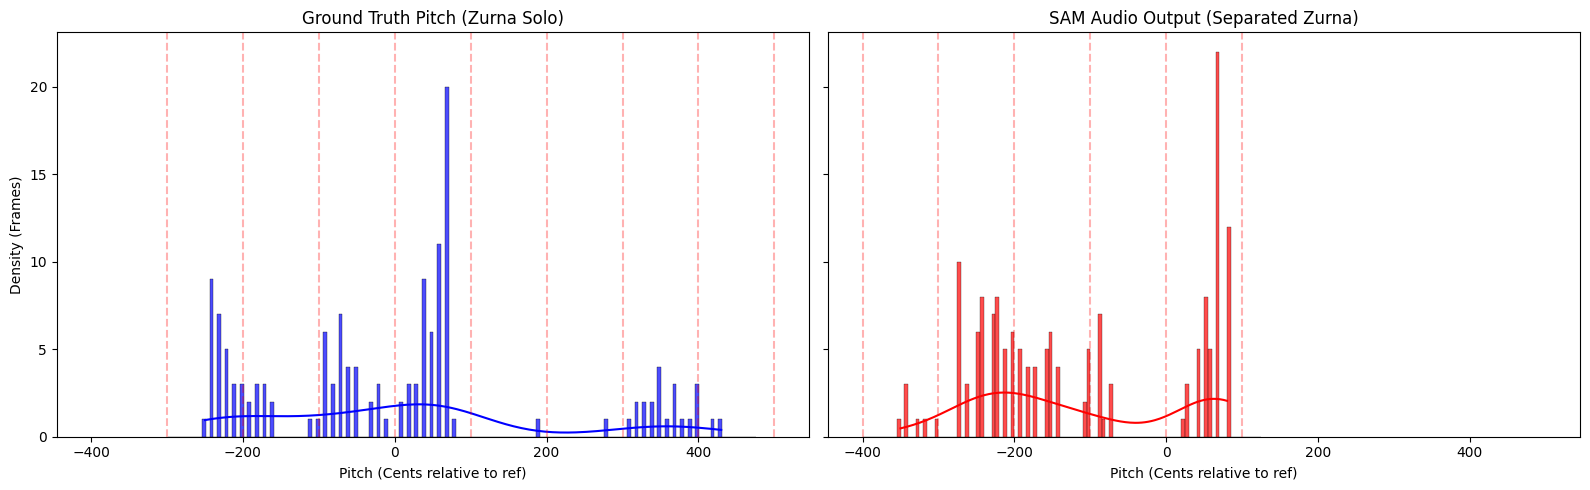

Analyzing zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_12.wav
  -> Extracting F0 with pyin...


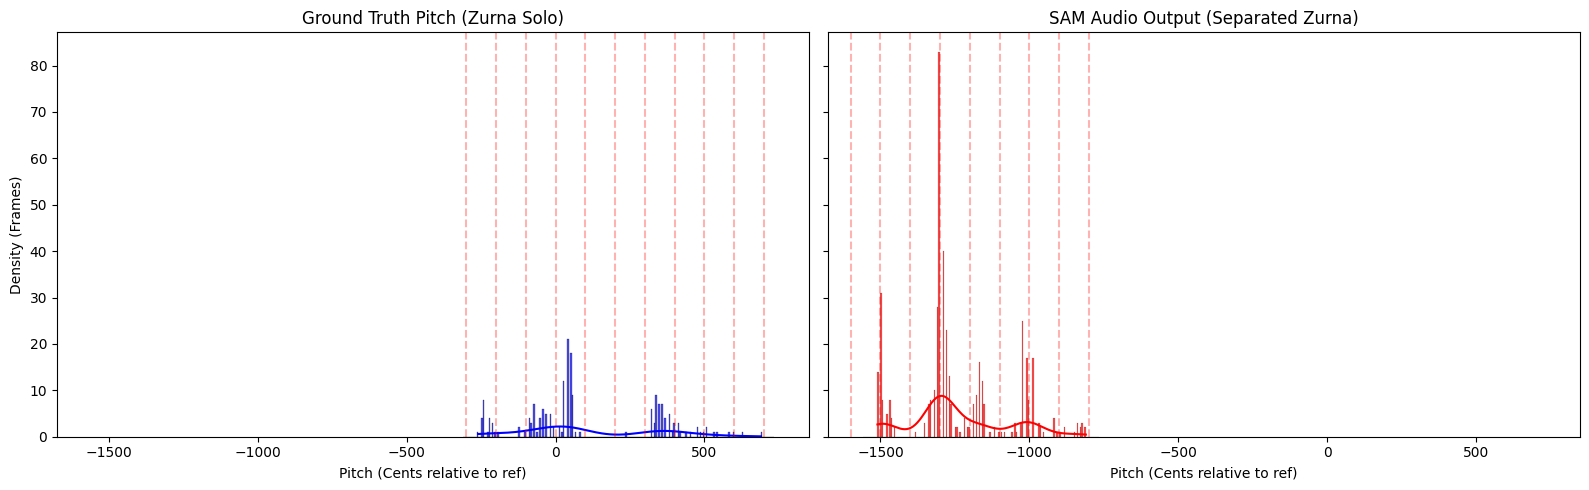

Analyzing zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_26.wav
  -> Extracting F0 with pyin...


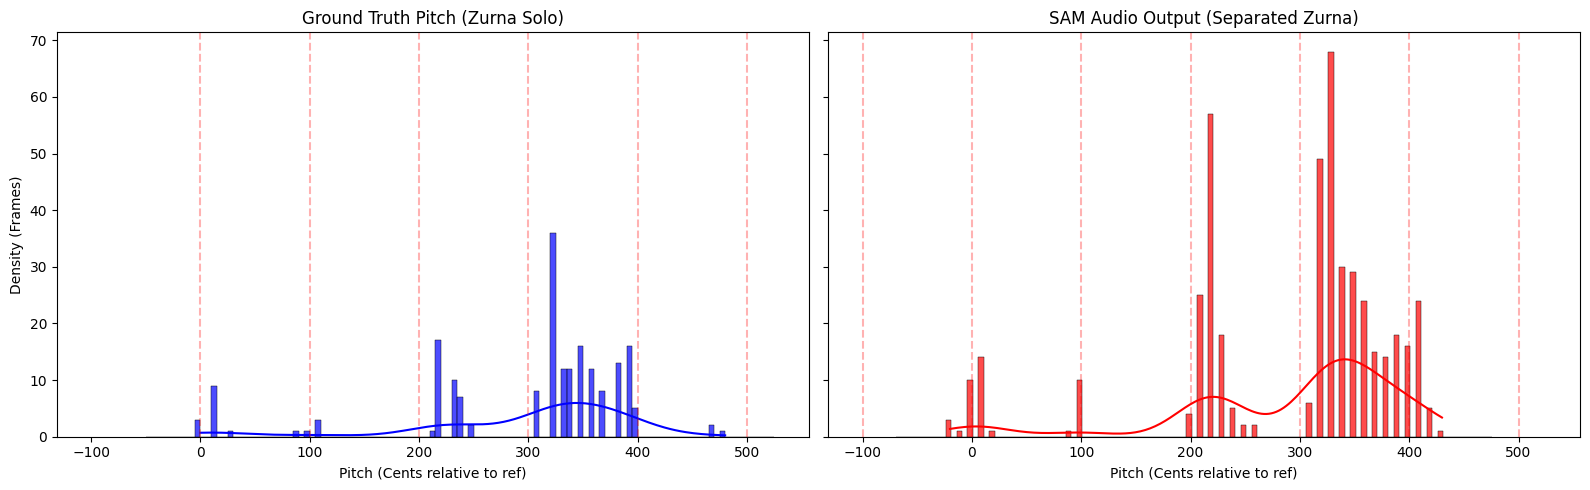

Analyzing zurna_YEd4i5phVBo-Zurna ｜ Sade Saz ｜ 8. Bölüm @trt2_38.wav
  -> Extracting F0 with pyin...


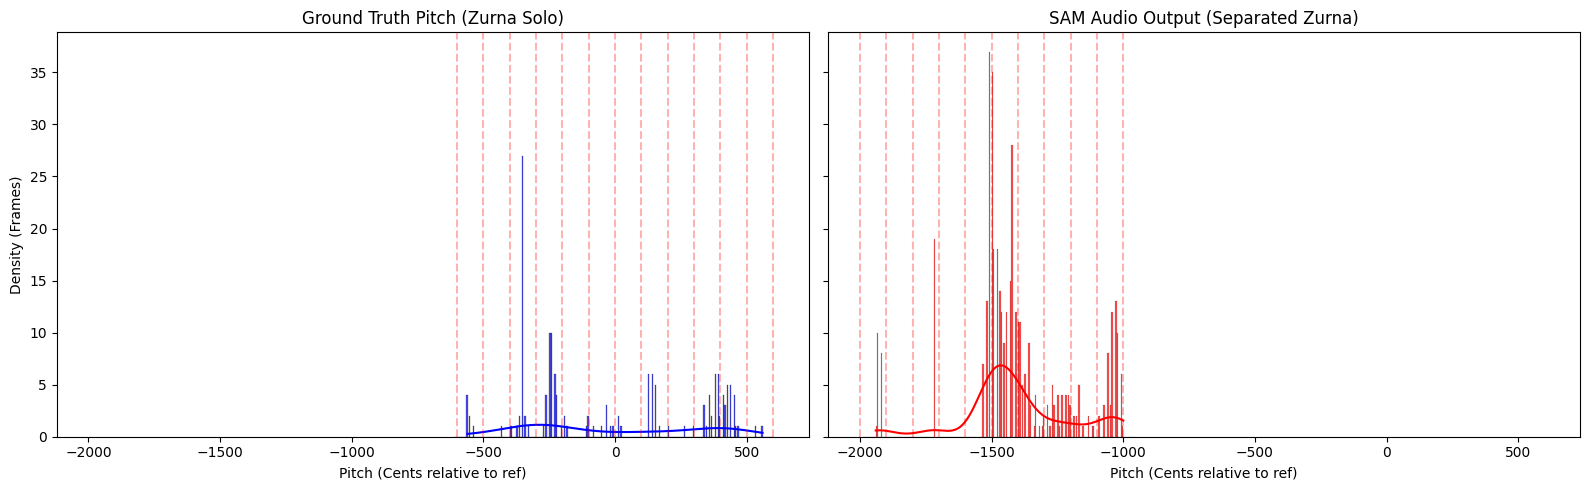

Analyzing zurna_QdICkMsgmMI-Zurna_2.wav
  -> Extracting F0 with pyin...


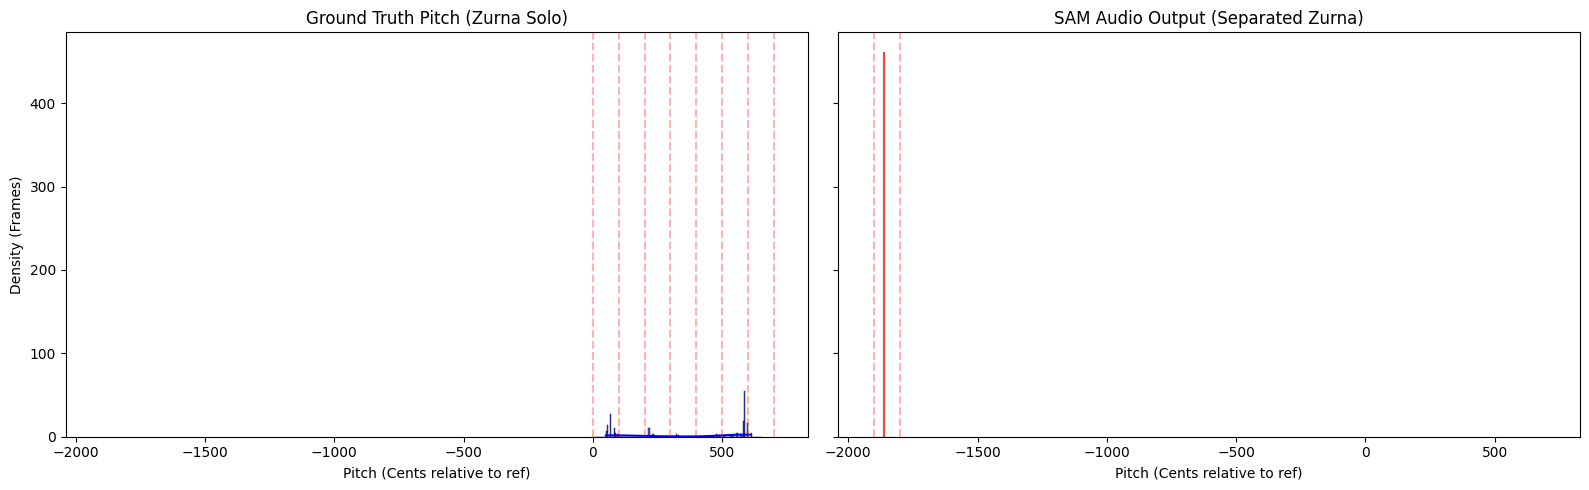

Analyzing zurna_QdICkMsgmMI-Zurna_7.wav
  -> Extracting F0 with pyin...


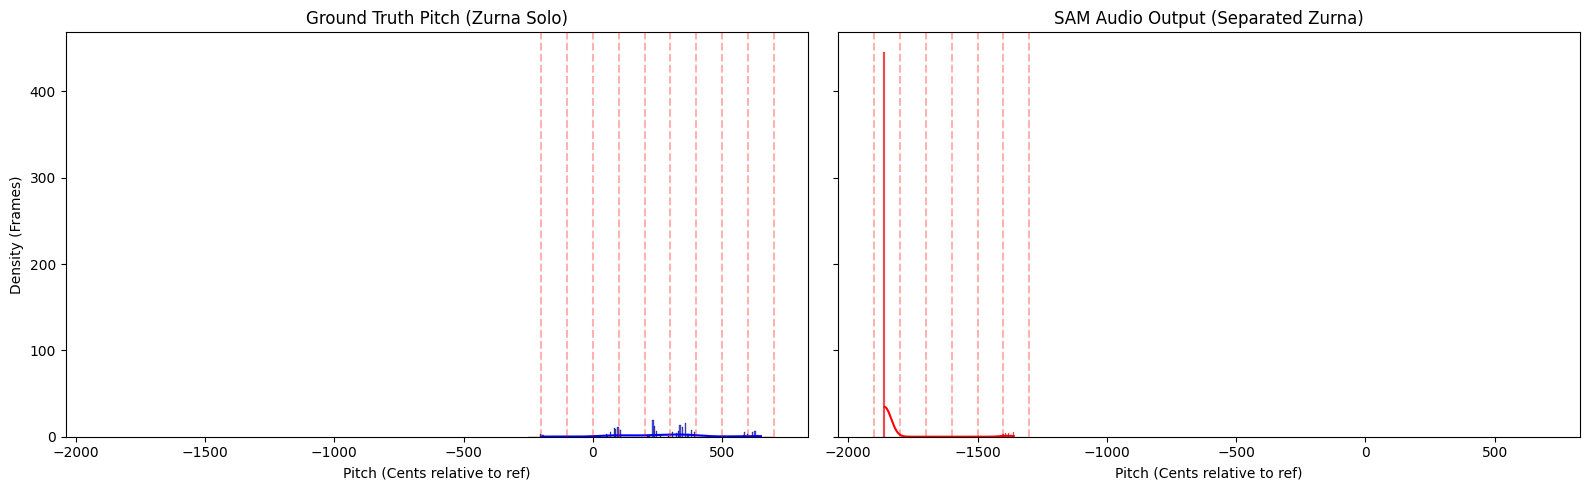

Analyzing zurna_QdICkMsgmMI-Zurna_13.wav
  -> Extracting F0 with pyin...


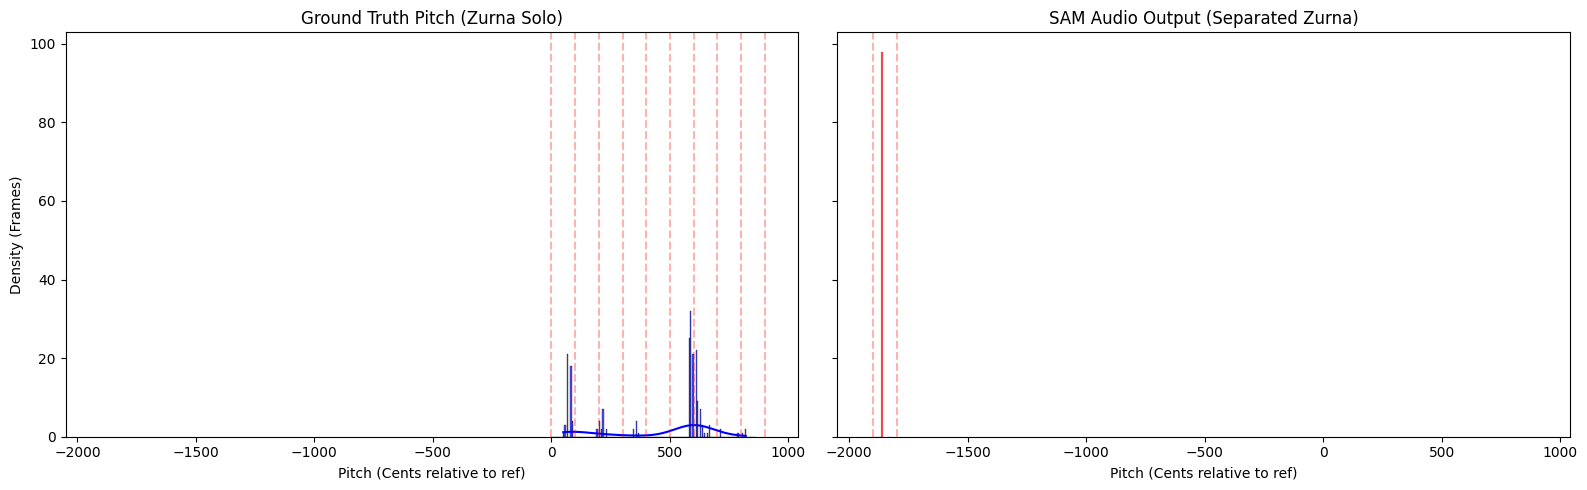

In [6]:
for gt_path, sam_path in file_pairs:
    analyze_snippet(gt_path, sam_path)